In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.draw import disk
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

In [13]:
def draw_foci(image_path, df, showplot = True, save_image = True, save_path = ""):
    # Load image
    image = Image.open(image_path)
    arr = np.array(image) # convert image to numpy matrix

    # Plot image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(arr, cmap="gray")

    # Draw red circles
    for _, row in df.iterrows():
        x = row["x_pixel"]
        y = row["y_pixel"]
        r = row["sigma_pixel"]

        circle = Circle(
            (x, y),
            r,
            fill=False,
            edgecolor="red",
            linewidth=1
        )

        ax.add_patch(circle)

    # Match image coordinates
    ax.set_xlim(0, arr.shape[1])
    ax.set_ylim(arr.shape[0], 0)

    # Show image
    if showplot:
        plt.show(fig)

    # Save image
    if save_image: 
        plt.savefig(save_path,
            dpi=300,
            bbox_inches="tight"
        )

        # Do not display image
        plt.close(fig)

In [16]:
image_path = "/mnt/c/users/elopatukhin/Desktop/190226/test/img_2.tif"
df_path = "/mnt/c/users/elopatukhin/Desktop/190226/test/foci.csv"

In [23]:
df = pd.read_csv(df_path)
len(df)

746

In [ ]:
lower_bound = 75
upper_bound = max(df['sigma_nm']) - max(df['sigma_nm'])*0.3

df_filtered = df[(df['sigma_nm'] > lower_bound) & (df['sigma_nm'] < 230)]


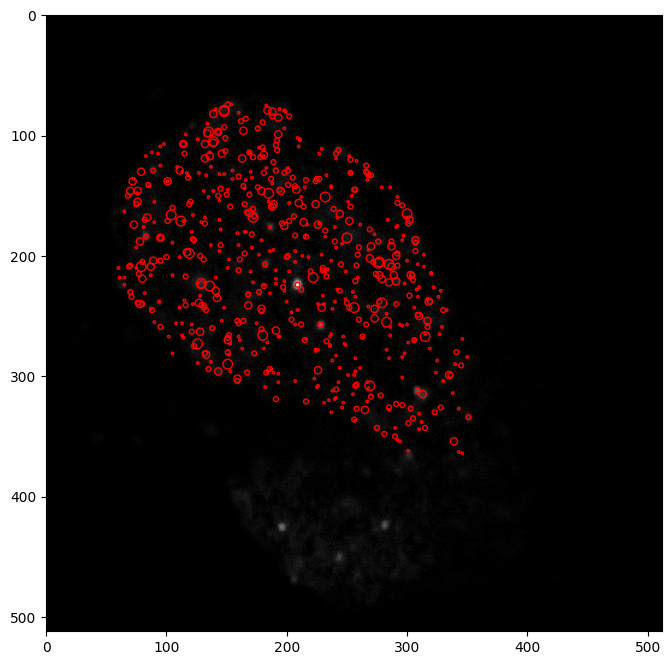

In [51]:
draw_foci(image_path, df_filtered, showplot = True, save_image = False, save_path = "")